# Coordinate Generation Analysis
Analyze model confidence and pixel attribution during bbox coordinate generation.

1. **Logit Confidence** - How confident is the model when selecting each coordinate?
2. **Pixel Saliency** - Which pixels drive each coordinate prediction?

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json, re
from pathlib import Path
from PIL import Image
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('/efs/user_folders/dnshalam/datasets/lvis')
model_name = 'Qwen/Qwen3-VL-8B-Instruct'
processor = AutoProcessor.from_pretrained(model_name)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_name, torch_dtype=torch.float16, device_map='auto',
)
model.eval()

with open(DATA_DIR / 'lvis_validation.json') as f:
    data = json.load(f)
print(f'Loaded model and {len(data)} samples')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded model and 244707 samples


In [2]:
# ── Generate with logit recording ──
def generate_with_logits(model, processor, image, prompt_text, max_new_tokens=128):
    """Generate tokens step-by-step, recording logit distributions."""
    messages = [{'role': 'user', 'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': prompt_text},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
    
    n_input = inputs['input_ids'].shape[1]
    
    # Use model.generate with output_scores to get per-step logits
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            return_dict_in_generate=True,
            output_scores=True,
        )
    
    generated_ids = output.sequences[0, n_input:]
    gen_text = processor.decode(generated_ids, skip_special_tokens=False)
    
    records = []
    for i, score in enumerate(output.scores):
        logits = score[0]  # (vocab_size,)
        probs = F.softmax(logits.float(), dim=-1)
        tok_id = generated_ids[i].item()
        entropy = -(probs * torch.log(probs + 1e-10)).sum().item()
        top_k_vals, top_k_ids = torch.topk(probs, k=10)
        
        records.append({
            'token_id': tok_id,
            'token_str': processor.tokenizer.decode(tok_id),
            'prob': probs[tok_id].item(),
            'entropy': entropy,
            'top_k_tokens': [processor.tokenizer.decode(t.item()) for t in top_k_ids],
            'top_k_probs': top_k_vals.cpu().numpy(),
        })
    
    return records, n_input, inputs



In [3]:
def find_bbox_token_ranges(records):
    """Find token indices for each coordinate in bbox_2d output."""
    tokens = [r['token_str'] for r in records]
    full_text = ''.join(tokens)
    
    m = re.search(r'"bbox_2d"\s*:\s*\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]', full_text)
    if not m:
        print(f'No bbox found in: {full_text[:200]}')
        return None
    
    coord_names = ['x1', 'y1', 'x2', 'y2']
    coord_ranges = {}  # name -> list of step indices
    
    char_pos = 0
    for step_idx, tok_str in enumerate(tokens):
        tok_start = char_pos
        tok_end = char_pos + len(tok_str)
        for i, name in enumerate(coord_names):
            coord_start = m.start(i + 1)
            coord_end = m.end(i + 1)
            if tok_start < coord_end and tok_end > coord_start:
                if name not in coord_ranges:
                    coord_ranges[name] = []
                coord_ranges[name].append(step_idx)
        char_pos = tok_end
    
    return coord_ranges

In [4]:
# ── Run on a sample ──
SAMPLE_IDX = 1000  # <-- change to explore

item = data[SAMPLE_IDX]
prompt_text = item['conversations'][0]['value'].replace('<image>\n', '')
image = Image.open(item['image']).convert('RGB')

print(f'Prompt: {prompt_text}')
records, n_input, inputs = generate_with_logits(model, processor, image, prompt_text)
gen_text = ''.join(r['token_str'] for r in records)
print(f'Generated: {gen_text[:200]}')

coord_ranges = find_bbox_token_ranges(records)
print(f'Coordinate token ranges: {coord_ranges}')

Prompt: Locate doughnut in this image and output the bbox coordinates in JSON format.
Generated: ```json
[
	{"bbox_2d": [536, 577, 612, 634], "label": "doughnut"}
]
```<|im_end|>
Coordinate token ranges: {'x1': [12, 13, 14], 'y1': [17, 18, 19], 'x2': [22, 23, 24], 'y2': [27, 28, 29]}


## 1. Logit Confidence per Coordinate

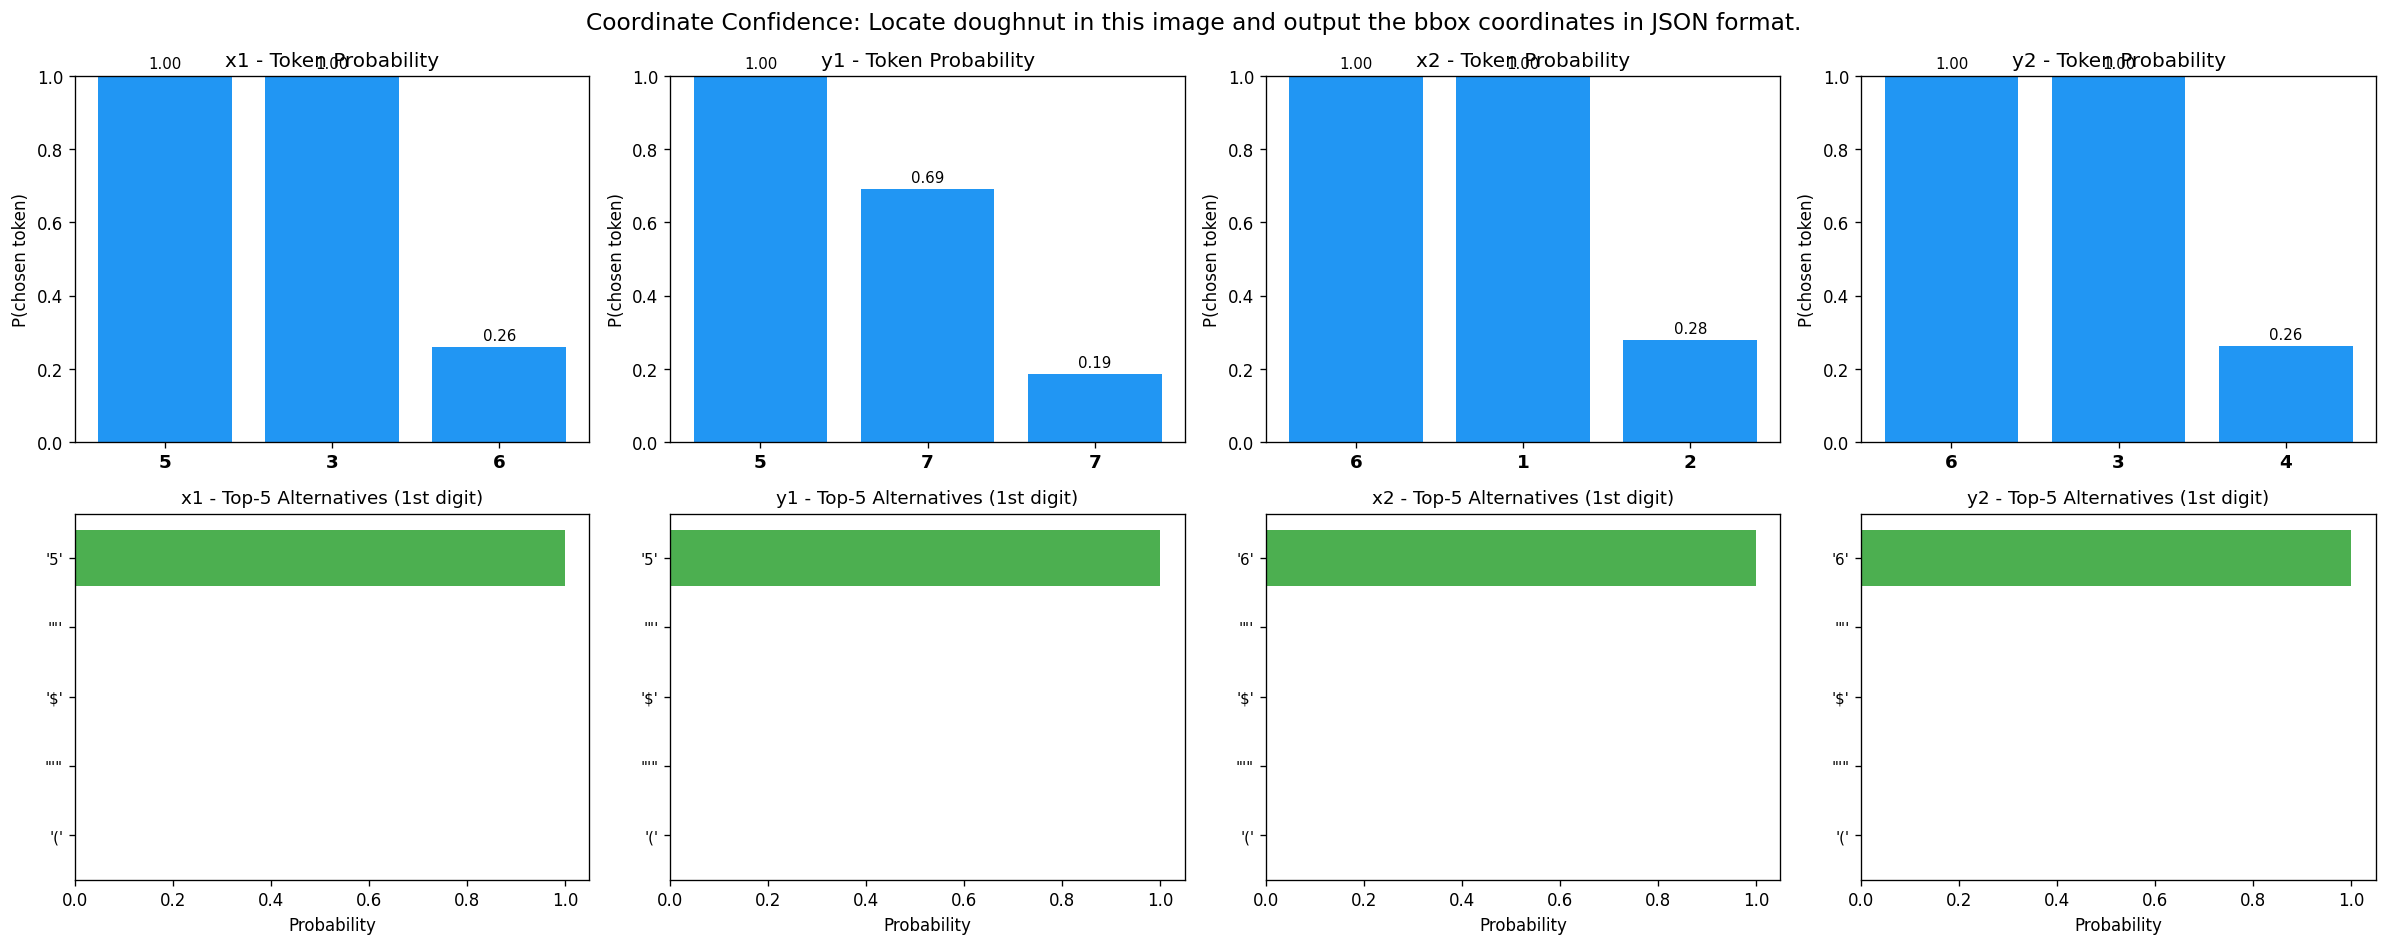

In [5]:
if coord_ranges:
    coord_names = ['x1', 'y1', 'x2', 'y2']
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    
    for col, name in enumerate(coord_names):
        if name not in coord_ranges:
            continue
        steps = coord_ranges[name]
        
        # Top row: probability of chosen token at each digit
        ax = axes[0, col]
        probs = [records[s]['prob'] for s in steps]
        digit_labels = [records[s]['token_str'] for s in steps]
        bars = ax.bar(range(len(steps)), probs, color='#2196F3')
        ax.set_xticks(range(len(steps)))
        ax.set_xticklabels(digit_labels, fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.set_title(f'{name} - Token Probability', fontsize=12)
        ax.set_ylabel('P(chosen token)')
        for bar, p in zip(bars, probs):
            ax.text(bar.get_x() + bar.get_width()/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
        
        # Bottom row: top-5 alternatives at first digit
        ax = axes[1, col]
        s = steps[0]  # first digit is most interesting
        top_tokens = records[s]['top_k_tokens'][:5]
        top_probs = records[s]['top_k_probs'][:5]
        colors = ['#4CAF50'] + ['#FF9800'] * 4
        ax.barh(range(len(top_tokens)-1, -1, -1), top_probs, color=colors)
        ax.set_yticks(range(len(top_tokens)-1, -1, -1))
        ax.set_yticklabels([repr(t) for t in top_tokens], fontsize=9)
        ax.set_title(f'{name} - Top-5 Alternatives (1st digit)', fontsize=11)
        ax.set_xlabel('Probability')
    
    fig.suptitle(f'Coordinate Confidence: {prompt_text}', fontsize=14)
    plt.tight_layout()
    plt.show()

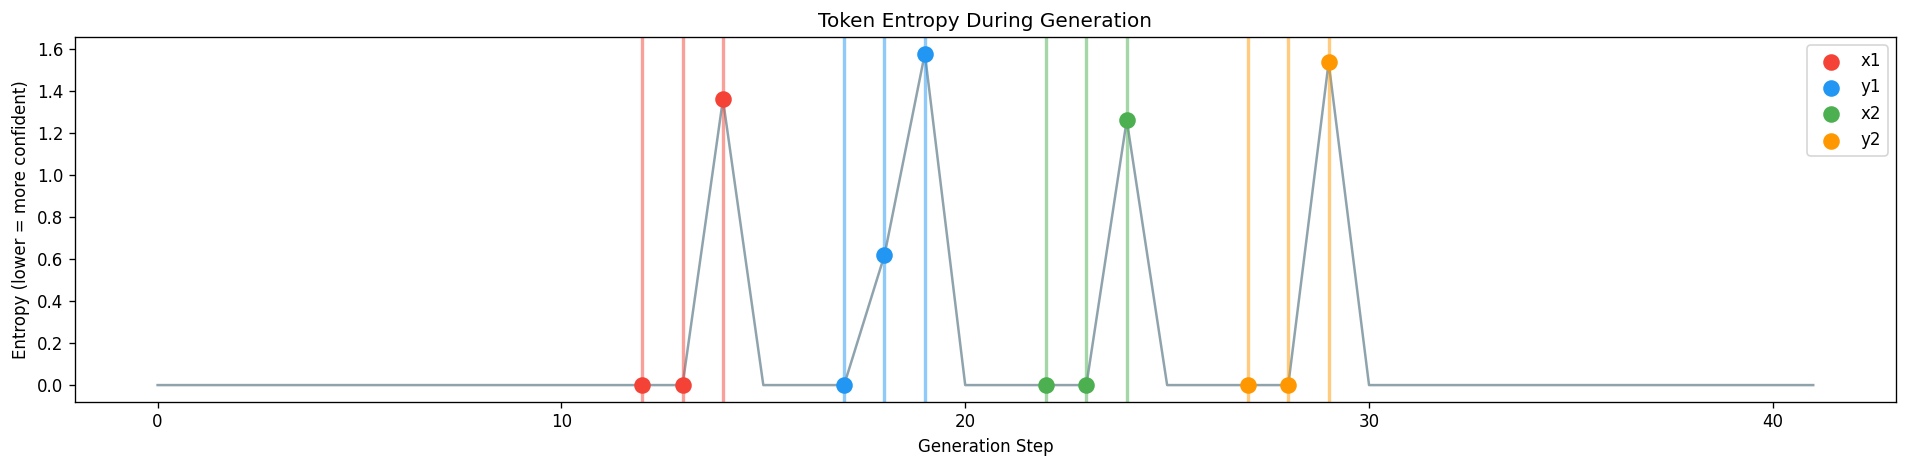

In [6]:
# Entropy across all generated tokens (lower = more confident)
if coord_ranges:
    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    entropies = [r['entropy'] for r in records]
    ax.plot(entropies, color='#607D8B', alpha=0.7)
    
    # Highlight coordinate tokens
    colors = {'x1': '#F44336', 'y1': '#2196F3', 'x2': '#4CAF50', 'y2': '#FF9800'}
    for name, steps in coord_ranges.items():
        for s in steps:
            ax.axvline(s, color=colors[name], alpha=0.5, lw=2)
        ax.scatter(steps, [entropies[s] for s in steps], color=colors[name], 
                   s=80, zorder=5, label=name)
    
    ax.set_xlabel('Generation Step')
    ax.set_ylabel('Entropy (lower = more confident)')
    ax.set_title('Token Entropy During Generation')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2. Pixel Saliency (Gradient × Input)
Which pixels drive each coordinate prediction?

In [7]:
def compute_pixel_saliency(model, processor, image, prompt_text, target_step, records):
    """Compute patch-level gradient saliency, mapped to image space."""
    messages = [{'role': 'user', 'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': prompt_text},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
    
    grid_thw = inputs['image_grid_thw'][0]  # [T, H, W]
    grid_h, grid_w = grid_thw[1].item(), grid_thw[2].item()
    
    generated_ids = torch.tensor([[r['token_id'] for r in records[:target_step + 1]]], device=model.device)
    input_ids = torch.cat([inputs['input_ids'], generated_ids], dim=-1)
    attn_mask = torch.ones_like(input_ids)
    pixel_values = inputs['pixel_values'].clone().detach().requires_grad_(True)
    static_inputs = {k: v for k, v in inputs.items()
                     if k not in ('input_ids', 'attention_mask', 'pixel_values')}
    
    out = model(input_ids=input_ids, attention_mask=attn_mask,
                pixel_values=pixel_values, **static_inputs)
    
    logits = out.logits[0, -1, :]
    chosen_logit = logits[records[target_step]['token_id']]
    model.zero_grad()
    chosen_logit.backward()
    
    if pixel_values.grad is None:
        print('  Warning: no gradient on pixel_values')
        return None
    
    # Gradient magnitude per patch: (1200, 1536) -> (1200,)
    grad_magnitude = pixel_values.grad.detach().cpu().float().abs().mean(dim=-1)
    
    # Reshape to spatial grid: (1200,) -> (40, 30)
    saliency = grad_magnitude[:grid_h * grid_w].reshape(grid_h, grid_w).numpy()
    
    # Resize to image dimensions
    saliency = np.array(Image.fromarray(saliency).resize(
        (image.width, image.height), Image.BILINEAR))
    
    return saliency


Computing saliency for x1 (step 12)...
Computing saliency for y1 (step 17)...
Computing saliency for x2 (step 22)...
Computing saliency for y2 (step 27)...


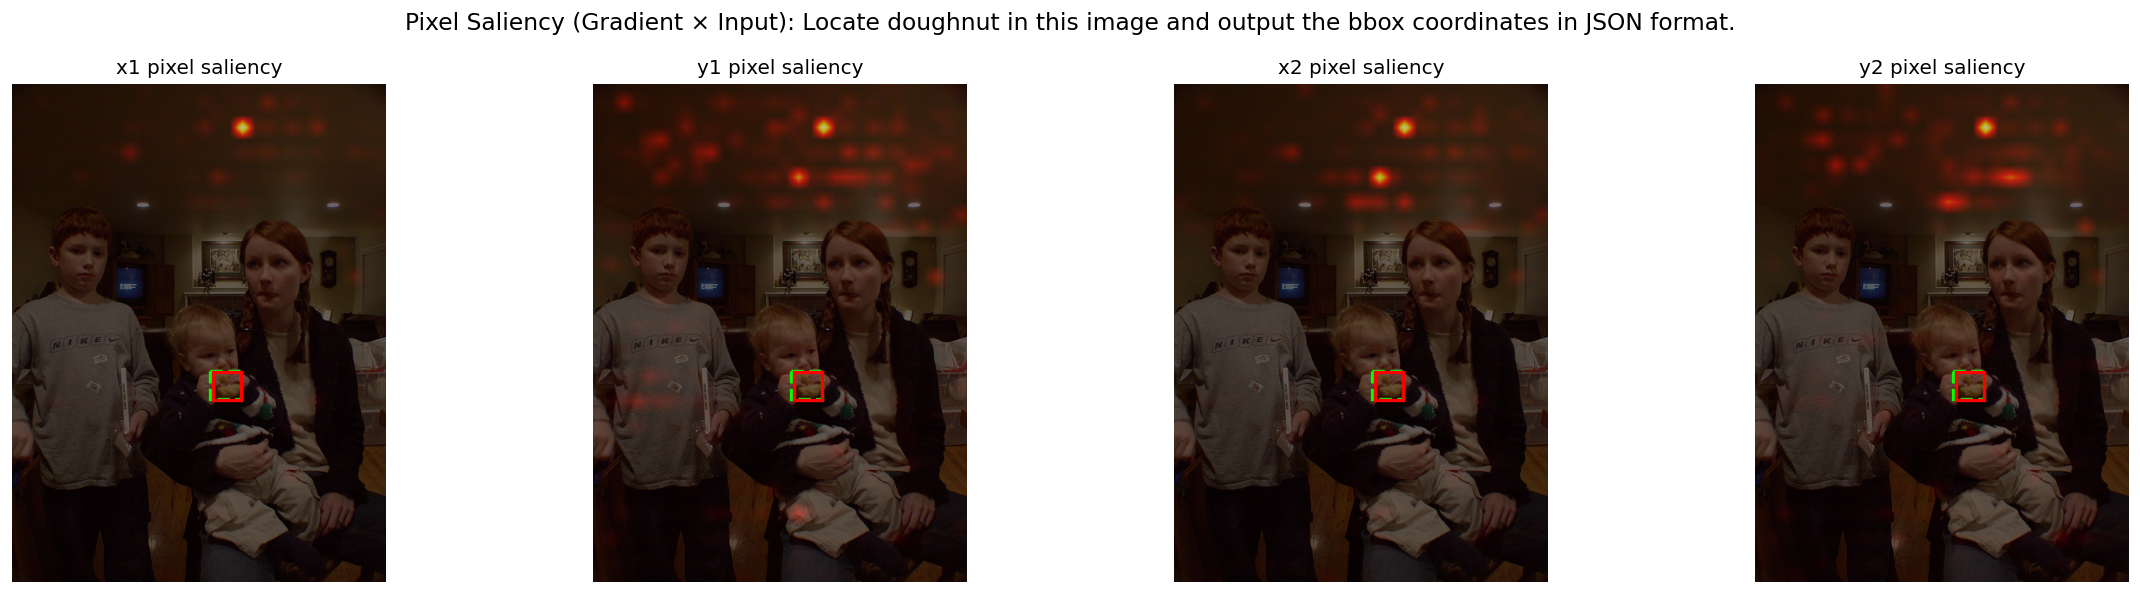

In [8]:
# Compute saliency for each coordinate's first digit
if coord_ranges:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    gt_match = re.search(r'<box>\((\d+),(\d+)\),\((\d+),(\d+)\)</box>', 
                         item['conversations'][1]['value'])
    if not gt_match:
        gt_match = re.search(r'"bbox_2d"\s*:\s*\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]',
                             item['conversations'][1]['value'])
    gt_coords = [int(gt_match.group(i)) for i in range(1, 5)] if gt_match else None
    
    for col, name in enumerate(['x1', 'y1', 'x2', 'y2']):
        ax = axes[col]
        ax.imshow(image)
        
        if name in coord_ranges:
            target_step = coord_ranges[name][0]
            print(f'Computing saliency for {name} (step {target_step})...')
            
            try:
                saliency = compute_pixel_saliency(model, processor, image, prompt_text, target_step, records)
                if saliency is not None:
                    sal_resized = np.array(Image.fromarray(saliency).resize(
                        (image.width, image.height), Image.BILINEAR))
                    ax.imshow(sal_resized, alpha=0.6, cmap='hot')
            except Exception as e:
                print(f'  Saliency failed for {name}: {e}')
        
        # GT box (green dash)
        if gt_coords:
            gx1, gy1, gx2, gy2 = [c/1000 for c in gt_coords]
            rect = patches.Rectangle((gx1*image.width, gy1*image.height),
                (gx2-gx1)*image.width, (gy2-gy1)*image.height,
                lw=2, ec='lime', fc='none', ls='--')
            ax.add_patch(rect)
        
        # Predicted box (red solid)
        pred_match = re.search(r'"bbox_2d"\s*:\s*\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]', gen_text)
        if pred_match:
            px1, py1, px2, py2 = [int(pred_match.group(i))/1000 for i in range(1, 5)]
            rect_pred = patches.Rectangle((px1*image.width, py1*image.height),
                (px2-px1)*image.width, (py2-py1)*image.height,
                lw=2, ec='red', fc='none')
            ax.add_patch(rect_pred)
            
        ax.set_title(f'{name} pixel saliency', fontsize=12)
        ax.axis('off')
    
    fig.suptitle(f'Pixel Saliency (Gradient × Input): {prompt_text}', fontsize=14)
    plt.tight_layout()
    plt.show()

Processed 10/1000
Processed 20/1000
Processed 30/1000
Processed 40/1000
Processed 50/1000
Processed 60/1000
Processed 70/1000
Processed 80/1000
Processed 90/1000
Processed 100/1000
Processed 110/1000
Processed 120/1000
Processed 130/1000
Processed 140/1000
Processed 150/1000
Processed 160/1000
Processed 170/1000
Processed 180/1000
Processed 190/1000
Processed 200/1000
Processed 210/1000
Processed 220/1000
Processed 230/1000
Processed 240/1000
Processed 250/1000
Processed 260/1000
Processed 270/1000
Processed 280/1000
Processed 290/1000
Processed 300/1000
Processed 310/1000
Processed 320/1000
Processed 330/1000
Processed 340/1000
Processed 350/1000
Processed 360/1000
Processed 370/1000
Processed 380/1000
Processed 390/1000
Processed 400/1000
Processed 410/1000
Processed 420/1000
Processed 430/1000
Processed 440/1000
Processed 450/1000
Processed 460/1000
Processed 470/1000
Processed 480/1000
Processed 490/1000
Processed 500/1000
Processed 510/1000
Processed 520/1000
Processed 530/1000
Pr

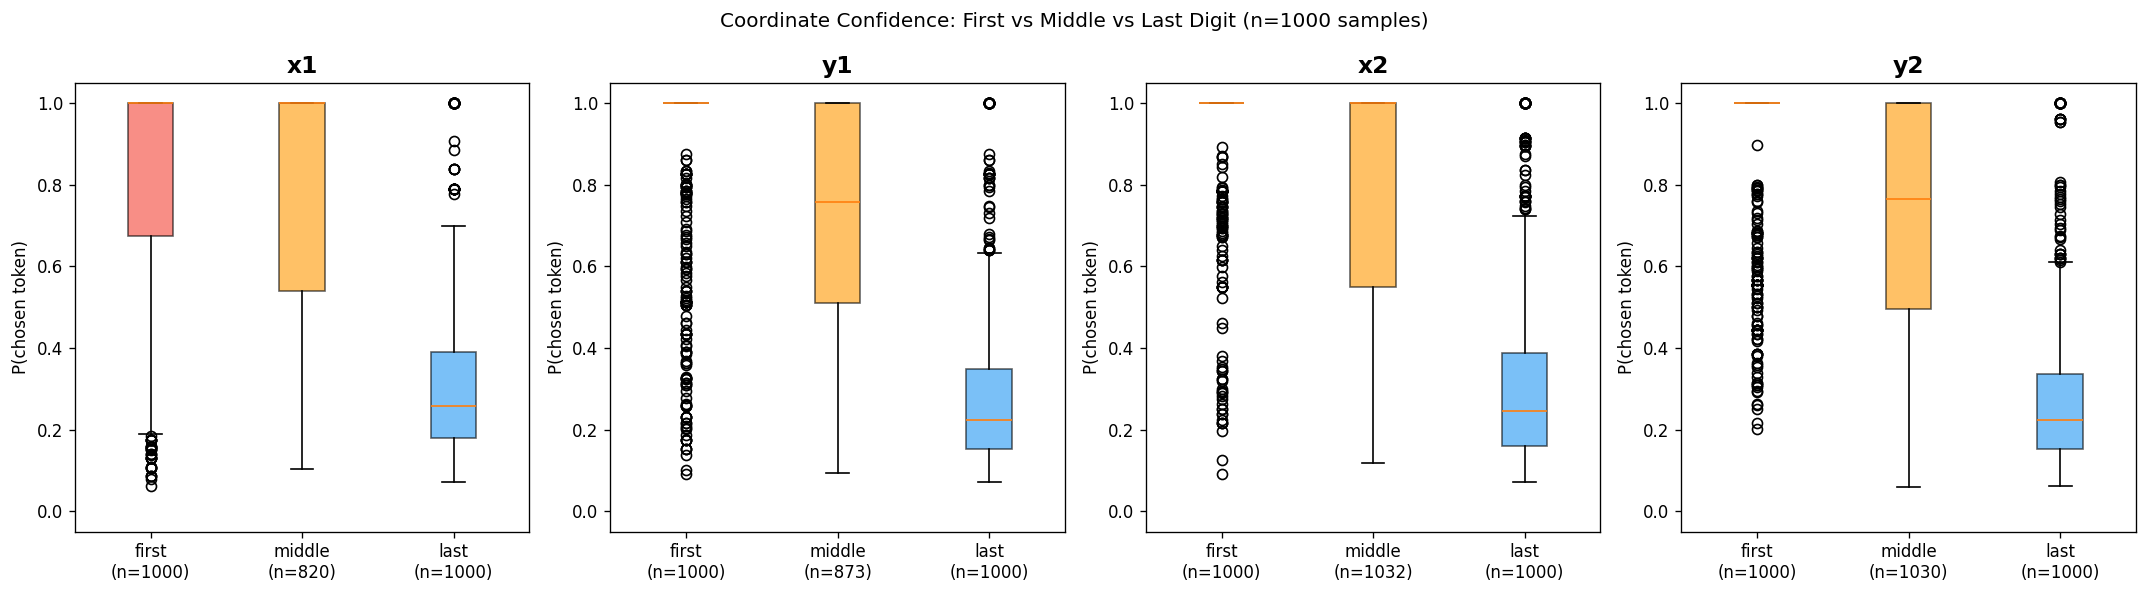


Mean confidence by digit position:
Coord       First     Middle       Last
----------------------------------------
x1          0.826      0.761      0.332
y1          0.935      0.728      0.293
x2          0.955      0.786      0.326
y2          0.946      0.734      0.289


In [9]:
# ── Confidence pattern across multiple samples ──

N_SAMPLES = 1000
# Track by relative position: first digit, middle digits, last digit
pos_probs = {name: {'first': [], 'middle': [], 'last': []} for name in ['x1', 'y1', 'x2', 'y2']}

for idx in range(N_SAMPLES):
    item = data[idx]
    prompt_text = item['conversations'][0]['value'].replace('<image>\n', '')
    img = Image.open(item['image']).convert('RGB')
    
    try:
        recs, _, _ = generate_with_logits(model, processor, img, prompt_text)
        cranges = find_bbox_token_ranges(recs)
        if not cranges:
            continue
        for name in ['x1', 'y1', 'x2', 'y2']:
            if name in cranges:
                steps = cranges[name]
                n = len(steps)
                if n >= 1:
                    pos_probs[name]['first'].append(recs[steps[0]]['prob'])
                    pos_probs[name]['last'].append(recs[steps[-1]]['prob'])
                if n >= 3:
                    for s in steps[1:-1]:
                        pos_probs[name]['middle'].append(recs[s]['prob'])
    except Exception as e:
        continue
    
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{N_SAMPLES}")

# Plot
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#F44336', '#FF9800', '#2196F3']
pos_names = ['first', 'middle', 'last']

for col, name in enumerate(['x1', 'y1', 'x2', 'y2']):
    ax = axes[col]
    values = [pos_probs[name][p] for p in pos_names if pos_probs[name][p]]
    labels = [f'{p}\n(n={len(pos_probs[name][p])})' for p in pos_names if pos_probs[name][p]]
    
    if values:
        bp = ax.boxplot(values, patch_artist=True)
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.6)
        ax.set_xticklabels(labels)
    
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('P(chosen token)')
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')

fig.suptitle(f'Coordinate Confidence: First vs Middle vs Last Digit (n={N_SAMPLES} samples)', fontsize=12)
plt.tight_layout()
plt.show()

# Summary
print("\nMean confidence by digit position:")
print(f"{'Coord':<6} {'First':>10} {'Middle':>10} {'Last':>10}")
print("-" * 40)
for name in ['x1', 'y1', 'x2', 'y2']:
    vals = [f"{np.mean(pos_probs[name][p]):.3f}" if pos_probs[name][p] else "N/A" 
            for p in pos_names]
    print(f"{name:<6} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

